In [27]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

df_customers = pd.read_csv(r"C:\Users\yassine\Downloads\MallCustomers.csv")

df_customers.head()

print(df_customers.info())

print(df_customers.isnull().sum())

# Traitement des valeurs manquantes 
median_age = df_customers['Age'].median()
df_customers['Age'] = df_customers['Age'].fillna(median_age)
print(f"\n-> Valeurs manquantes de 'Age' traitées (remplacées par la médiane : {median_age})")

print(df_customers.isnull().sum())

# Conversion des variables catégoriques 
df_customers['Gender'] = df_customers['Gender'].map({'Male': 0, 'Female': 1})

df_customers.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              200 non-null    int64  
 1   Gender                  200 non-null    object 
 2   Age                     195 non-null    float64
 3   Annual Income (k$)      200 non-null    int64  
 4   Spending Score (1-100)  200 non-null    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Gender                    0
Age                       5
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

-> Valeurs manquantes de 'Age' traitées (remplacées par la médiane : 36.0)
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19.0,15,39
1,2,0,21.0,15,81
2,3,1,20.0,16,6
3,4,1,23.0,16,77
4,5,1,31.0,17,40


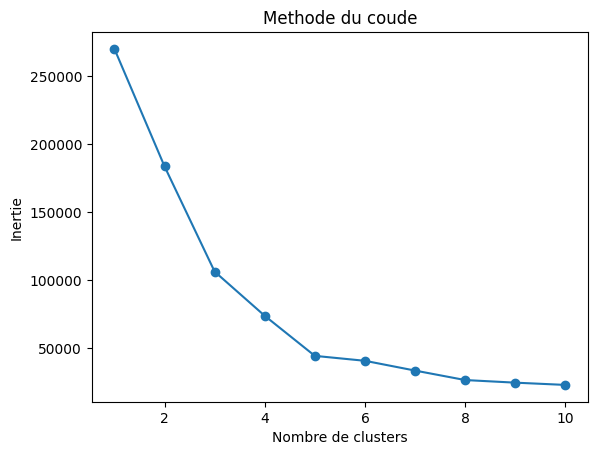

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
X = df_customers[["Annual Income (k$)"  , "Spending Score (1-100)"]]
inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia , marker ='o')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.title('Methode du coude')
plt.show()


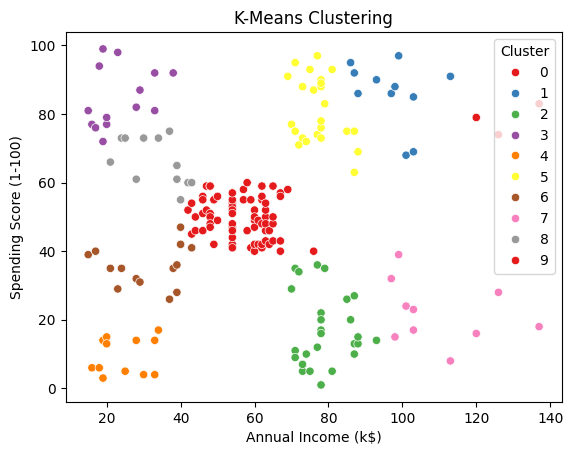

In [29]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)

df_customers["Cluster"] = kmeans.labels_

sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)", hue="Cluster", data=df_customers, palette="Set1")
plt.title("K-Means Clustering")
plt.show()

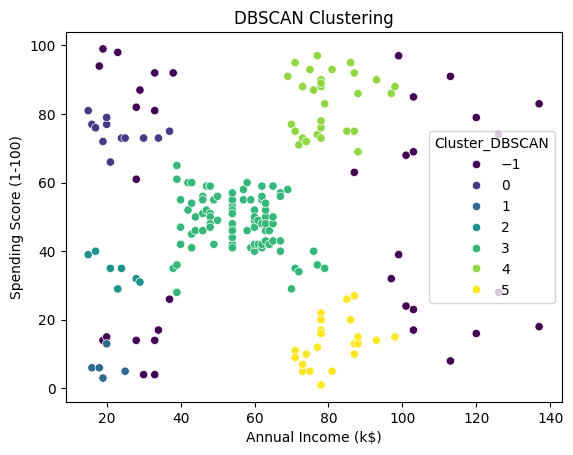

In [30]:
from sklearn.cluster import DBSCAN
import seaborn as sns

dbscan = DBSCAN(eps=8 , min_samples=5)
df_customers["Cluster_DBSCAN"] = dbscan.fit_predict(X)

sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)",
hue="Cluster_DBSCAN" , data=df_customers , palette="viridis")
plt.title("DBSCAN Clustering")
plt.show()

In [31]:
Birch(
    threshold=0.5,     
    branching_factor=50,
    n_clusters=5
)


,"threshold threshold: float, default=0.5The radius of the subcluster obtained by merging a new sample and theclosest subcluster should be lesser than the threshold. Otherwise a newsubcluster is started. Setting this value to be very low promotessplitting and vice-versa.",0.5
,"branching_factor branching_factor: int, default=50Maximum number of CF subclusters in each node. If a new samples enterssuch that the number of subclusters exceed the branching_factor thenthat node is split into two nodes with the subclusters redistributedin each. The parent subcluster of that node is removed and two newsubclusters are added as parents of the 2 split nodes.",50
,"n_clusters n_clusters: int, instance of sklearn.cluster model or None, default=3Number of clusters after the final clustering step, which treats thesubclusters from the leaves as new samples.- `None` : the final clustering step is not performed and the subclusters are returned as they are.- :mod:`sklearn.cluster` Estimator : If a model is provided, the model is fit treating the subclusters as new samples and the initial data is mapped to the label of the closest subcluster.- `int` : the model fit is :class:`AgglomerativeClustering` with `n_clusters` set to be equal to the int.",5
,"compute_labels compute_labels: bool, default=TrueWhether or not to compute labels for each fit.",True


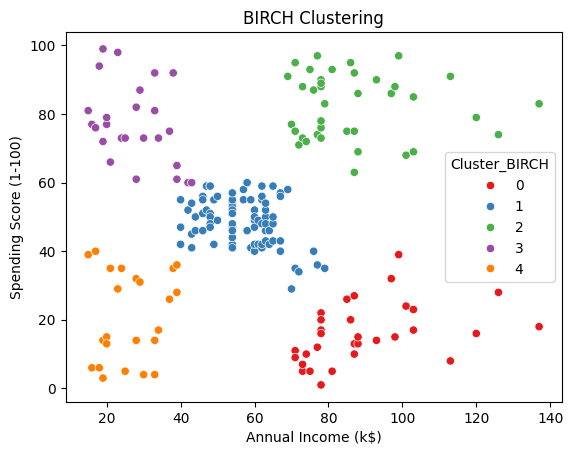

In [32]:
from sklearn.cluster import Birch
import seaborn as sns
import matplotlib.pyplot as plt

birch = Birch(n_clusters=5)  
df_customers["Cluster_BIRCH"] = birch.fit_predict(X)

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster_BIRCH",
    data=df_customers,
    palette="Set1"
)

plt.title("BIRCH Clustering")
plt.show()
